# 0.6 Glamsterdam Regular-Gas Recalculation

The execution_gas under Glamsterdam cannot be simply calculated as:

```text
historical gas_used - historical_state_creation_gas
```

That misses two transaction-level Glamsterdam changes:

1. EIP-7976 raises the calldata-heavy transaction floor to `64 * calldata_bytes`.
2. EIP-7981 adds an access-list data surcharge of `64 gas/byte`.

The important shape is transaction-level:

```text
regular_gas_tx = 21_000 + access_list_data_cost_7981
               + max(standard_branch_after_state, 64 * calldata_bytes)
```

Then the block-level EIP-8037 baseline still uses:

```text
gas_used_8037 = max(block_regular_gas_used, block_state_gas_8037)
```

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dotenv import load_dotenv
import clickhouse_connect

from basefee.eip1559 import update_eip1559_base_fee
from glamsterdam.calldata_floor import (
    HISTORICAL_AUTH_BASE_GAS,
    glamsterdam_regular_gas_from_receipt,
)
from sim.xatu_glamsterdam import (
    query_xatu_transaction_gas_inputs,
    query_xatu_tx_state_creation,
)

load_dotenv(PROJECT_ROOT / ".env")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

START_BLOCK = 24_120_001
N_BLOCKS = 500
END_BLOCK = START_BLOCK + N_BLOCKS - 1
BLOCKS = list(range(START_BLOCK, END_BLOCK + 1))
NETWORK = "mainnet"

EXECUTION_STATE_TARGET = 30_000_000
EXECUTION_STATE_LIMIT = 60_000_000

TX_INPUTS_CSV = DATA_DIR / f"glamsterdam_tx_inputs_{START_BLOCK}_{END_BLOCK}.csv"
TX_STATE_CSV = DATA_DIR / f"glamsterdam_tx_state_creation_xatu_{START_BLOCK}_{END_BLOCK}.csv"
TX_REPRICED_CSV = DATA_DIR / f"glamsterdam_tx_regular_gas_repriced_{START_BLOCK}_{END_BLOCK}.csv"
BLOCK_REPRICED_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_{START_BLOCK}_{END_BLOCK}.csv"
SUMMARY_CSV = DATA_DIR / f"glamsterdam_regular_gas_recalculation_summary_{START_BLOCK}_{END_BLOCK}.csv"

XATU_STATE_CSV = DATA_DIR / f"xatu_state_growth_{START_BLOCK}_{END_BLOCK}.csv"
STATE_REPLAY_CSV = DATA_DIR / f"state_gas_for_replay_{START_BLOCK}_{END_BLOCK}.csv"
ACCESS_LIST_RECORDS_CSV = DATA_DIR / f"rpc_access_list_records_{START_BLOCK}_{END_BLOCK}.csv"
AUTH_SUMMARY_CSV = DATA_DIR / f"rpc_authorization_summary_{START_BLOCK}_{END_BLOCK}.csv"
OLD_REPLAY_CSV = DATA_DIR / f"glamsterdam_only_replay_{START_BLOCK}_{END_BLOCK}.csv"

## Load or Pull Transaction Inputs

The transaction input helper uses Xatu in two layers:

- raw `execution_transaction` is the source of transaction membership, position,
  hash, gas limit, type, and calldata zero/nonzero bytes
- `canonical_execution_transaction` is joined only for receipt `gas_used`

This matters because `canonical_execution_transaction` can be sparse on some
historical ranges. The helper validates raw transaction counts against beacon
payload transaction counts and validates that every raw transaction has a joined
canonical receipt-gas row. If either check fails, the notebook stops and the range
should use RPC full blocks/receipts instead.

In [2]:
if TX_INPUTS_CSV.exists():
    tx_inputs = pd.read_csv(TX_INPUTS_CSV)
else:
    missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
    if missing:
        raise RuntimeError("Missing .env values: " + ", ".join(missing))
    raw_host = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
    raw_client = clickhouse_connect.get_client(
        host=raw_host,
        port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
        username=os.environ["CLICKHOUSE_USER"],
        password=os.environ["CLICKHOUSE_PASSWORD"],
        secure=True,
    )
    tx_inputs = query_xatu_transaction_gas_inputs(raw_client, BLOCKS, network=NETWORK)
    tx_inputs.to_csv(TX_INPUTS_CSV, index=False)

tx_inputs.head()

,block_number,tx_index,tx_hash,transaction_type,to_address,receipt_gas_used,tx_gas_limit,calldata_zero_bytes,calldata_nonzero_bytes,calldata_bytes,standard_calldata_gas
0,24120001,0,0x891f32f375b516ac7357292b7fdc5846fad710e8c284...,2,0x80a64c6d7f12c47b7c66c5b4e20e72bc1fcd5d9e,176062,306380,166,94,260,2168
1,24120001,1,0xe26644f9c42a1965ee30d70fc135fcdb1868c74f9cae...,2,0x3a10dc1a145da500d5fba38b9ec49c8ff11a981f,267440,446416,304,84,388,2560
2,24120001,2,0x4e1ee9fe1c375875a1d71aaf97c3f388c60b6abe59d7...,2,0x420cafe478ebb83542a70089e5a65da67cc829ac,134948,218656,1,24,25,388
3,24120001,3,0x671e0d8bfb3b11f4418834800650f29012a1e9598709...,2,0x5e1f62dac767b0491e3ce72469c217365d5b48cc,299209,549900,1037,311,1348,9124
4,24120001,4,0xa5a54bd6dd0d6100b34441aaba6cc1946ca51d7ad8fb...,2,0x420cafe478ebb83542a70089e5a65da67cc829ac,98601,173035,0,25,25,400


## Pull Transaction-Level Historical State Creation

The EIP-8037 state side is already in `state_gas_for_replay`. For the regular-gas
branch, however, the old state-creation gas should be removed before applying the
Glamsterdam calldata floor.

Xatu raw diff tables expose `transaction_hash` / `transaction_index`, so storage
slot creation, new-account proxies, and code bytes can be attached to transactions.

EIP-7702 delegation indicators remain calibrated through the RPC path. The exact
block-level count is merged below as a small block-level correction because the
cached authorization summary does not identify the exact newly-delegating tuple
without replaying prestate per authorization.

In [3]:
if TX_STATE_CSV.exists():
    tx_state = pd.read_csv(TX_STATE_CSV)
else:
    missing = [name for name in ["CLICKHOUSE_USER", "CLICKHOUSE_PASSWORD"] if not os.environ.get(name)]
    if missing:
        raise RuntimeError("Missing .env values: " + ", ".join(missing))
    raw_host = os.environ.get("CLICKHOUSE_RAW_HOST", "clickhouse-raw.xatu.ethpandaops.io")
    raw_client = clickhouse_connect.get_client(
        host=raw_host,
        port=int(os.environ.get("CLICKHOUSE_PORT", "443")),
        username=os.environ["CLICKHOUSE_USER"],
        password=os.environ["CLICKHOUSE_PASSWORD"],
        secure=True,
    )
    tx_state = query_xatu_tx_state_creation(raw_client, BLOCKS, network=NETWORK)
    tx_state.to_csv(TX_STATE_CSV, index=False)

tx_state.head()

,block_number,tx_index,tx_hash,new_storage_slots,new_accounts,code_bytes,new_delegation_indicators,historical_state_creation_gas
0,24120001,0,0x891f32f375b516ac7357292b7fdc5846fad710e8c284...,1,0,0,0,20000
1,24120001,2,0x4e1ee9fe1c375875a1d71aaf97c3f388c60b6abe59d7...,1,0,0,0,20000
2,24120001,5,0x3fc58cb14c3836f887709f6f05297c5bacd356e3bb15...,0,1,0,0,25000
3,24120001,6,0xe07f2d72cef1773a8462ee65d9e95bf6bcc1b2838b1c...,1,0,0,0,20000
4,24120001,8,0xc2e0b12b95c5efc0f66e9acf5da4c2092de1c640d746...,14,1,216,0,348200


## Join Access Lists and Reprice Each Transaction

EIP-7981 access-list data bytes are pulled from the existing RPC access-list file.
For each transaction we compute:

```text
body_gas_after_state = receipt_gas_used - 21_000 - old_state_creation_gas_tx
regular_gas_tx       = 21_000 + access_list_data_cost_7981
                     + max(body_gas_after_state, 64 * calldata_bytes)
```

For transactions that were already EIP-7623-floor-bound, the exact EVM execution
branch is partially unobserved. That is okay for the Glamsterdam floor test when
`64 * calldata_bytes` dominates the current floor, but the notebook keeps an
observed-current-floor flag so the uncertainty is visible.

In [4]:
access_records = pd.read_csv(ACCESS_LIST_RECORDS_CSV)
access_cols = [
    "block_number",
    "tx_index",
    "tx_hash",
    "tx_access_list_address_count",
    "tx_access_list_storage_key_count",
]
access_records = access_records[access_cols]

state_cols = [
    "block_number",
    "tx_index",
    "tx_hash",
    "new_storage_slots",
    "new_accounts",
    "code_bytes",
    "historical_state_creation_gas",
]

tx = (
    tx_inputs.merge(access_records, on=["block_number", "tx_index", "tx_hash"], how="left", validate="one_to_one")
    .merge(tx_state[state_cols], on=["block_number", "tx_index", "tx_hash"], how="left", validate="one_to_one")
    .sort_values(["block_number", "tx_index"])
    .reset_index(drop=True)
)

fill_zero_cols = [
    "tx_access_list_address_count",
    "tx_access_list_storage_key_count",
    "new_storage_slots",
    "new_accounts",
    "code_bytes",
    "historical_state_creation_gas",
]
for column in fill_zero_cols:
    tx[column] = tx[column].fillna(0).astype("int64")

results = []
for row in tx.itertuples(index=False):
    result = glamsterdam_regular_gas_from_receipt(
        receipt_gas_used=int(row.receipt_gas_used),
        calldata_zero_bytes=int(row.calldata_zero_bytes),
        calldata_nonzero_bytes=int(row.calldata_nonzero_bytes),
        access_list_address_count=int(row.tx_access_list_address_count),
        access_list_storage_key_count=int(row.tx_access_list_storage_key_count),
        historical_state_creation_gas_used=int(row.historical_state_creation_gas),
    )
    results.append(result.__dict__)

result_df = pd.DataFrame(results)
result_df = result_df[[column for column in result_df.columns if column not in tx.columns]]
repriced = pd.concat([tx, result_df], axis=1)
repriced.to_csv(TX_REPRICED_CSV, index=False)
repriced.head()

,block_number,tx_index,tx_hash,transaction_type,to_address,receipt_gas_used,tx_gas_limit,calldata_zero_bytes,calldata_nonzero_bytes,calldata_bytes,...,access_list_storage_key_count,access_list_bytes,access_list_cost_2930,access_list_data_cost_7981,standard_branch_after_state,floor_branch,floor_binds,floor_uplift,current_floor_binds_observed,regular_gas_glamsterdam
0,24120001,0,0x891f32f375b516ac7357292b7fdc5846fad710e8c284...,2,0x80a64c6d7f12c47b7c66c5b4e20e72bc1fcd5d9e,176062,306380,166,94,260,...,0,0,0,0,135062,16640,False,0,False,156062
1,24120001,1,0xe26644f9c42a1965ee30d70fc135fcdb1868c74f9cae...,2,0x3a10dc1a145da500d5fba38b9ec49c8ff11a981f,267440,446416,304,84,388,...,0,0,0,0,246440,24832,False,0,False,267440
2,24120001,2,0x4e1ee9fe1c375875a1d71aaf97c3f388c60b6abe59d7...,2,0x420cafe478ebb83542a70089e5a65da67cc829ac,134948,218656,1,24,25,...,22,764,49000,48896,93948,1600,False,0,False,163844
3,24120001,3,0x671e0d8bfb3b11f4418834800650f29012a1e9598709...,2,0x5e1f62dac767b0491e3ce72469c217365d5b48cc,299209,549900,1037,311,1348,...,0,0,0,0,278209,86272,False,0,False,299209
4,24120001,4,0xa5a54bd6dd0d6100b34441aaba6cc1946ca51d7ad8fb...,2,0x420cafe478ebb83542a70089e5a65da67cc829ac,98601,173035,0,25,25,...,19,668,43300,42752,77601,1600,False,0,False,141353


## Aggregate to Blocks and Merge EIP-8037 State Gas

The transaction-level repricing handles storage/account/code state de-accounting
inside the calldata-floor max. Delegation indicators are then subtracted as a tiny
block-level correction so the historical state-creation subtraction stays aligned
with the passive replay and with the RPC-calibrated `state_gas_for_replay` table.

The Xatu transaction-level account proxy can differ from the RPC-calibrated passive replay
block total by a one-account-sized amount on a few blocks. The notebook keeps this
visible as `historical_state_creation_alignment_correction` and applies it at
block level, so total historical state de-accounting matches the passive replay input.

In [5]:
xatu_state = pd.read_csv(XATU_STATE_CSV)
state_replay = pd.read_csv(STATE_REPLAY_CSV)
auth_summary = pd.read_csv(AUTH_SUMMARY_CSV) if AUTH_SUMMARY_CSV.exists() else pd.DataFrame({"block_number": BLOCKS})
old_replay = pd.read_csv(OLD_REPLAY_CSV) if OLD_REPLAY_CSV.exists() else pd.DataFrame({"block_number": BLOCKS})

block = repriced.groupby("block_number", as_index=False).agg(
    tx_count=("tx_hash", "count"),
    current_gas_used_from_txs=("receipt_gas_used", "sum"),
    historical_state_creation_gas_tx=("historical_state_creation_gas", "sum"),
    current_7623_floor_bound_txs=("current_floor_binds_observed", "sum"),
    glamsterdam_7976_floor_bound_txs=("floor_binds", "sum"),
    glamsterdam_7976_floor_uplift=("floor_uplift", "sum"),
    access_list_data_cost_7981=("access_list_data_cost_7981", "sum"),
    regular_gas_glamsterdam_before_delegation=("regular_gas_glamsterdam", "sum"),
    calldata_bytes=("calldata_bytes", "sum"),
    standard_calldata_gas=("standard_calldata_gas", "sum"),
)

block = block.merge(
    xatu_state[["block_number", "timestamp", "gas_used", "gas_limit", "base_fee_per_gas", "gas_state_growth"]],
    on="block_number",
    how="left",
    validate="one_to_one",
)
block = block.merge(
    state_replay[
        [
            "block_number",
            "new_delegation_indicators",
            "state_gas_used_for_replay",
            "state_gas_source",
        ]
    ],
    on="block_number",
    how="left",
    validate="one_to_one",
)
if "authorization_tuple_count" in auth_summary.columns:
    block = block.merge(
        auth_summary[["block_number", "authorization_tuple_count"]],
        on="block_number",
        how="left",
        validate="one_to_one",
    )
else:
    block["authorization_tuple_count"] = 0

if "execution_gas_used" in old_replay.columns:
    block = block.merge(
        old_replay[
            [
                "block_number",
                "historical_state_creation_gas",
                "execution_gas_used",
                "gas_used_8037",
                "base_fee_with_8037",
            ]
        ].rename(
            columns={
                "historical_state_creation_gas": "old_08_historical_state_creation_gas",
                "execution_gas_used": "old_08_execution_gas_used",
                "gas_used_8037": "old_08_gas_used_8037",
                "base_fee_with_8037": "old_08_base_fee_with_8037",
            }
        ),
        on="block_number",
        how="left",
        validate="one_to_one",
    )

block["delegation_historical_state_creation_gas"] = (
    block["new_delegation_indicators"].fillna(0).astype("int64") * HISTORICAL_AUTH_BASE_GAS
)
block["historical_state_creation_gas_observed"] = (
    block["historical_state_creation_gas_tx"] + block["delegation_historical_state_creation_gas"]
)
if "old_08_historical_state_creation_gas" in block.columns:
    block["historical_state_creation_gas_total"] = block[
        "old_08_historical_state_creation_gas"
    ].astype("int64")
else:
    block["historical_state_creation_gas_total"] = block[
        "historical_state_creation_gas_observed"
    ]
block["historical_state_creation_alignment_correction"] = (
    block["historical_state_creation_gas_total"]
    - block["historical_state_creation_gas_observed"]
)
block["regular_gas_glamsterdam"] = (
    block["regular_gas_glamsterdam_before_delegation"]
    - block["delegation_historical_state_creation_gas"]
    - block["historical_state_creation_alignment_correction"]
).clip(lower=0).astype("int64")
block["state_gas_8037"] = block["state_gas_used_for_replay"].astype("int64")
block["gas_used_8037_repriced"] = block[["regular_gas_glamsterdam", "state_gas_8037"]].max(axis=1)
block["gas_used_8037_repriced_for_base_fee"] = block["gas_used_8037_repriced"].clip(upper=EXECUTION_STATE_LIMIT)
block["gas_used_8037_repriced_limit_exceeded"] = block["gas_used_8037_repriced"] > EXECUTION_STATE_LIMIT
block["bottleneck_repriced"] = "state"
block.loc[block["regular_gas_glamsterdam"] > block["state_gas_8037"], "bottleneck_repriced"] = "execution"
block.loc[block["regular_gas_glamsterdam"] == block["state_gas_8037"], "bottleneck_repriced"] = "tied"

block[[
    "block_number",
    "current_gas_used_from_txs",
    "gas_used",
    "regular_gas_glamsterdam",
    "state_gas_8037",
    "gas_used_8037_repriced",
    "glamsterdam_7976_floor_bound_txs",
    "glamsterdam_7976_floor_uplift",
    "access_list_data_cost_7981",
]].head()

,block_number,current_gas_used_from_txs,gas_used,regular_gas_glamsterdam,state_gas_8037,gas_used_8037_repriced,glamsterdam_7976_floor_bound_txs,glamsterdam_7976_floor_uplift,access_list_data_cost_7981
0,24120001,59964904,59964904,54038829,42310620,54038829,19,192249,466176
1,24120002,13753679,13753679,11765253,13693500,13693500,6,56574,0
2,24120003,41015898,41015898,34135767,43098570,43098570,13,386317,61952
3,24120004,23756933,23756933,19321970,31432320,31432320,11,232885,247552
4,24120005,16941785,16941785,15323901,13558860,15323901,11,131128,165888


## Recompute the EIP-8037 Base-Fee Path

This remains the Glamsterdam / EIP-8037 baseline: one shared execution/state fee,
updated with the EIP-1559 linear rule. The input is now the corrected regular-gas
counterfactual.

In [6]:
base_fees = []
base_fee = int(block["base_fee_per_gas"].iloc[0])
for row in block.itertuples(index=False):
    base_fees.append(base_fee)
    base_fee = update_eip1559_base_fee(
        parent_base_fee=base_fee,
        gas_used=int(row.gas_used_8037_repriced_for_base_fee),
        gas_target=EXECUTION_STATE_TARGET,
        min_base_fee=1,
    )

block["base_fee_with_8037_repriced_regular_gas"] = base_fees
block["base_fee_delta_repriced_minus_original"] = block["base_fee_with_8037_repriced_regular_gas"] - block["base_fee_per_gas"]
block["base_fee_ratio_repriced_to_original"] = block["base_fee_with_8037_repriced_regular_gas"] / block["base_fee_per_gas"]
if "old_08_base_fee_with_8037" in block.columns:
    block["base_fee_delta_repriced_minus_old_08"] = block["base_fee_with_8037_repriced_regular_gas"] - block["old_08_base_fee_with_8037"]

block.to_csv(BLOCK_REPRICED_CSV, index=False)
block.tail()

,block_number,tx_count,current_gas_used_from_txs,historical_state_creation_gas_tx,current_7623_floor_bound_txs,glamsterdam_7976_floor_bound_txs,glamsterdam_7976_floor_uplift,access_list_data_cost_7981,regular_gas_glamsterdam_before_delegation,calldata_bytes,...,regular_gas_glamsterdam,state_gas_8037,gas_used_8037_repriced,gas_used_8037_repriced_for_base_fee,gas_used_8037_repriced_limit_exceeded,bottleneck_repriced,base_fee_with_8037_repriced_regular_gas,base_fee_delta_repriced_minus_original,base_fee_ratio_repriced_to_original,base_fee_delta_repriced_minus_old_08
495,24120496,425,45212899,4345000,2,13,361573,339968,41944440,185627,...,41919440,24342300,41919440,41919440,False,execution,1890816019,1825120062,28.781315,1537146909
496,24120497,373,56862633,5197400,1,9,89611,405248,52435092,209710,...,52422592,29310210,52422592,52422592,False,execution,1984722136,1914861905,28.409899,1615074700
497,24120498,305,54715740,11780600,2,9,2151565,609280,46844735,254850,...,46844735,67818780,67818780,60000000,True,state,2170149697,2092470176,27.937218,1767152773
498,24120499,98,5940363,1025000,1,9,24938,0,5090301,18413,...,5090301,6058800,6058800,6058800,False,state,2441418409,2355739277,28.494901,1988046870
499,24120500,390,46947583,4975000,1,10,255980,208384,42811947,177606,...,42799447,26045190,42799447,42799447,False,execution,2197874716,2120784787,28.510530,1789729254


## Summary Metrics

The most important diagnostics are:

- how many transactions become EIP-7976 floor-bound
- how much EIP-7976 uplift is added
- how much EIP-7981 access-list data surcharge is added
- how the corrected regular gas changes the EIP-8037 bottleneck and base-fee path

In [7]:
summary = pd.DataFrame([
    {
        "blocks": len(block),
        "txs": int(block["tx_count"].sum()),
        "current_7623_floor_bound_txs": int(block["current_7623_floor_bound_txs"].sum()),
        "glamsterdam_7976_floor_bound_txs": int(block["glamsterdam_7976_floor_bound_txs"].sum()),
        "mean_current_gas_used": float(block["gas_used"].mean()),
        "mean_old_08_execution_gas_used": float(block.get("old_08_execution_gas_used", pd.Series(dtype=float)).mean()),
        "mean_regular_gas_glamsterdam": float(block["regular_gas_glamsterdam"].mean()),
        "mean_state_gas_8037": float(block["state_gas_8037"].mean()),
        "mean_gas_used_8037_repriced": float(block["gas_used_8037_repriced"].mean()),
        "mean_glamsterdam_7976_floor_uplift": float(block["glamsterdam_7976_floor_uplift"].mean()),
        "mean_access_list_data_cost_7981": float(block["access_list_data_cost_7981"].mean()),
        "max_abs_historical_state_alignment_correction": int(block["historical_state_creation_alignment_correction"].abs().max()),
        "execution_bottleneck_blocks": int((block["bottleneck_repriced"] == "execution").sum()),
        "state_bottleneck_blocks": int((block["bottleneck_repriced"] == "state").sum()),
        "target_exceed_blocks": int((block["gas_used_8037_repriced"] > EXECUTION_STATE_TARGET).sum()),
        "limit_exceed_blocks": int((block["gas_used_8037_repriced"] > EXECUTION_STATE_LIMIT).sum()),
        "initial_base_fee_repriced": int(block["base_fee_with_8037_repriced_regular_gas"].iloc[0]),
        "final_base_fee_repriced": int(block["base_fee_with_8037_repriced_regular_gas"].iloc[-1]),
        "final_original_base_fee": int(block["base_fee_per_gas"].iloc[-1]),
    }
])
summary.to_csv(SUMMARY_CSV, index=False)
summary.T

,0
blocks,5.000000e+02
txs,1.472460e+05
current_7623_floor_bound_txs,6.790000e+02
glamsterdam_7976_floor_bound_txs,4.689000e+03
mean_current_gas_used,3.047064e+07
mean_old_08_execution_gas_used,2.553493e+07
mean_regular_gas_glamsterdam,2.708514e+07
mean_state_gas_8037,2.866559e+07
mean_gas_used_8037_repriced,3.331631e+07
mean_glamsterdam_7976_floor_uplift,6.800676e+05


## Quick Plot

This plot is intentionally simple: it compares the old passive-replay execution proxy with
the corrected Glamsterdam regular-gas estimate, then shows the state bottleneck.

PosixPath('/Users/william/PycharmProjects/eip-7999-research/plots/glamsterdam_regular_gas_recalculation_24120001_24120500.png')

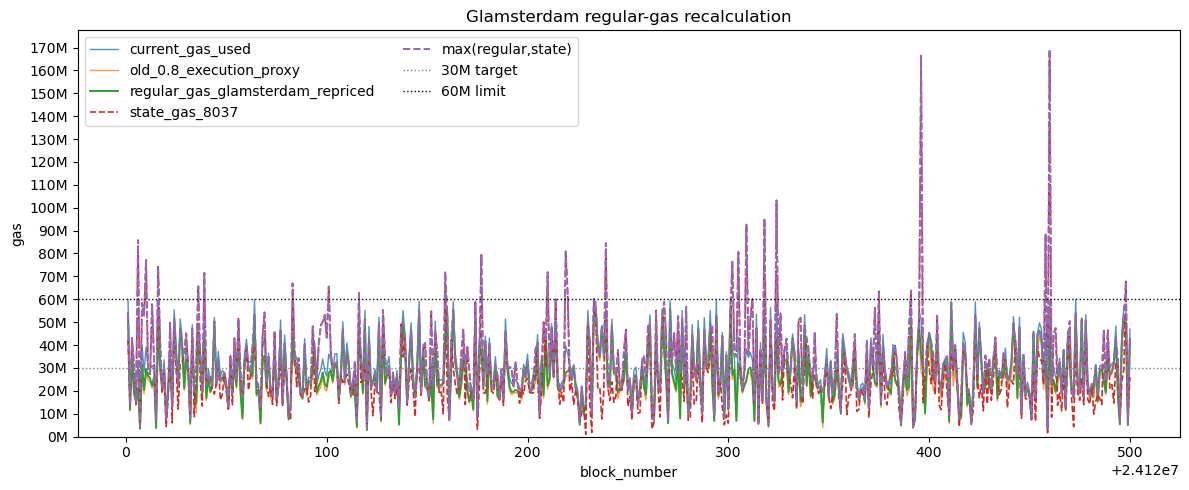

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator

plot_path = PLOTS_DIR / f"glamsterdam_regular_gas_recalculation_{START_BLOCK}_{END_BLOCK}.png"

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(block["block_number"], block["gas_used"], label="current_gas_used", linewidth=1.0, alpha=0.8)
if "old_08_execution_gas_used" in block.columns:
    ax.plot(block["block_number"], block["old_08_execution_gas_used"], label="old_passive_execution_proxy", linewidth=1.0, alpha=0.8)
ax.plot(block["block_number"], block["regular_gas_glamsterdam"], label="regular_gas_glamsterdam_repriced", linewidth=1.4)
ax.plot(block["block_number"], block["state_gas_8037"], label="state_gas_8037", linewidth=1.2, linestyle="--")
ax.plot(block["block_number"], block["gas_used_8037_repriced"], label="max(regular,state)", linewidth=1.4, linestyle="--")
ax.axhline(EXECUTION_STATE_TARGET, color="gray", linestyle=":", linewidth=1, label="30M target")
ax.axhline(EXECUTION_STATE_LIMIT, color="black", linestyle=":", linewidth=1, label="60M limit")
ax.yaxis.set_major_locator(MultipleLocator(10_000_000))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value/1_000_000:.0f}M"))
ax.set_ylim(bottom=0)
ax.set_xlabel("block_number")
ax.set_ylabel("gas")
ax.legend(ncol=2)
ax.set_title("Glamsterdam regular-gas recalculation")
fig.tight_layout()
fig.savefig(plot_path, dpi=160)
plot_path